Total Transactions: 515
Duplicate Records: 30
High-Value Transactions: 35
Suspicious Accounts: 7

Top 10 Highest Transactions:
Transaction_ID Account_ID    Amount Transaction_Category  Risk_Score
     TXN100468    ACC1014 249289.83             Shopping          70
     TXN100448    ACC1042 238533.79               Travel          85
     TXN100365    ACC1023 237890.76        Food & Dining          60
     TXN100036    ACC1002 233189.05                Bills          60
     TXN100413    ACC1011 229110.83             Shopping          85
     TXN100210    ACC1003 223650.73           Healthcare          95
     TXN100204    ACC1046 215490.22                Bills          60
     TXN100366    ACC1012 215277.94             Transfer          60
     TXN100230    ACC1070 213365.97                Bills          60
     TXN100233    ACC1056 206737.19           Healthcare          60


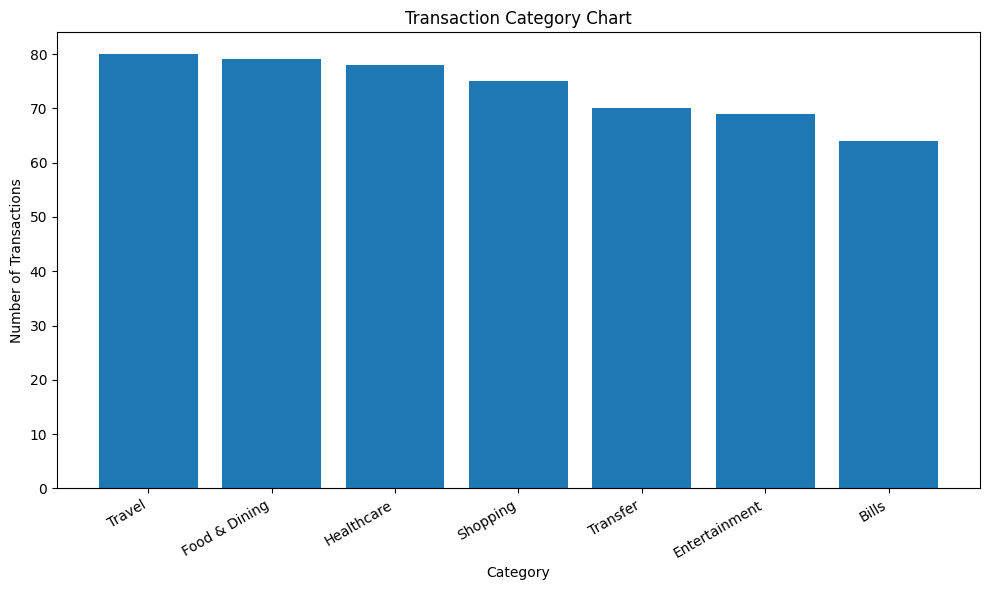

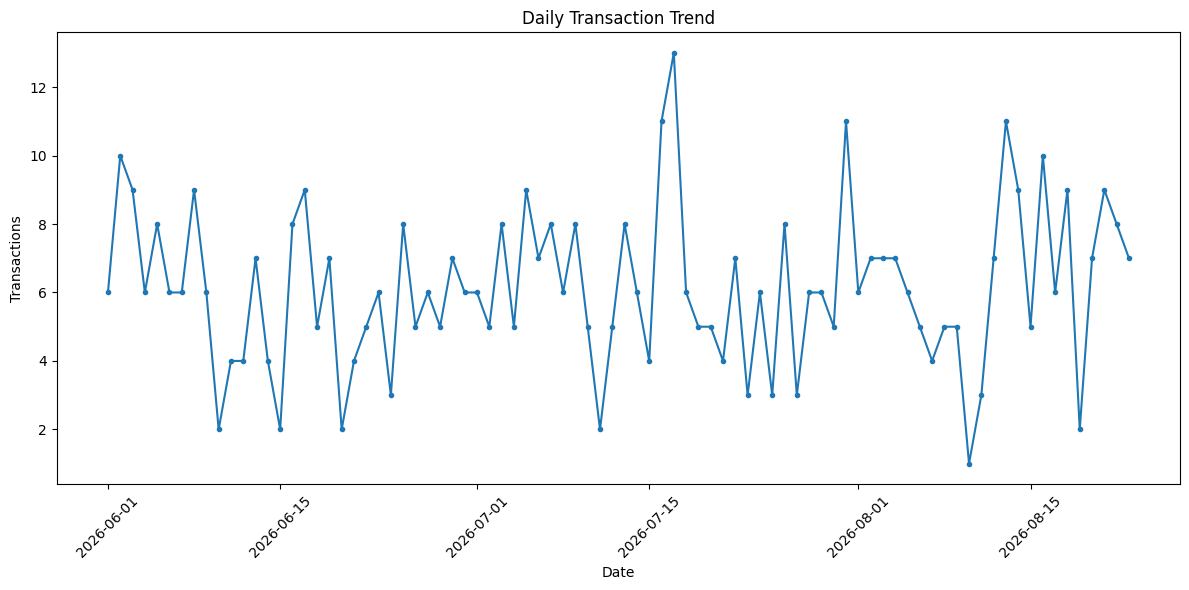

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('/content/')
df = pd.read_csv(BASE_DIR / "transactions_dataset.csv")
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

HIGH_VALUE_THRESHOLD = 50000
FREQUENT_TRANSACTION_THRESHOLD = 10

duplicates = df[df.duplicated(keep=False)].copy()
high_value_transactions = df[df["Amount"] > HIGH_VALUE_THRESHOLD].copy()

account_frequency = df.groupby("Account_ID").size().reset_index(name="Transaction_Count")
suspicious_accounts = account_frequency[
    account_frequency["Transaction_Count"] >= FREQUENT_TRANSACTION_THRESHOLD
]["Account_ID"]

df["Risk_Score"] = 0
df.loc[df["Amount"] > HIGH_VALUE_THRESHOLD, "Risk_Score"] += 40
df.loc[df["Amount"] > 100000, "Risk_Score"] += 20
df.loc[df["Account_ID"].isin(suspicious_accounts), "Risk_Score"] += 25
df.loc[df.duplicated(keep=False), "Risk_Score"] += 35
df.loc[df["Status"] == "Failed", "Risk_Score"] += 10
df["Risk_Score"] = df["Risk_Score"].clip(upper=100)

df["Risk_Level"] = pd.cut(
    df["Risk_Score"], [-1,24,49,74,100],
    labels=["Low","Medium","High","Critical"]
)

suspicious_transactions = df[
    (df["Risk_Score"] >= 50) | (df["Amount"] > HIGH_VALUE_THRESHOLD) | df.duplicated(keep=False)
].copy()
suspicious_transactions.to_csv(BASE_DIR / "suspicious_transactions.csv", index=False)

print("Total Transactions:", len(df))
print("Duplicate Records:", len(duplicates))
print("High-Value Transactions:", len(high_value_transactions))
print("Suspicious Accounts:", len(suspicious_accounts))
print("\nTop 10 Highest Transactions:")
print(df.nlargest(10, "Amount")[["Transaction_ID","Account_ID","Amount","Transaction_Category","Risk_Score"]].to_string(index=False))

category_counts = df["Transaction_Category"].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index, category_counts.values)
plt.title("Transaction Category Chart")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR / "transaction_category_chart.png", dpi=300)
plt.show()

df["Date"] = df["Transaction_Date"].dt.date
daily = df.groupby("Date").size()
plt.figure(figsize=(12,6))
plt.plot(daily.index, daily.values, marker="o", markersize=3)
plt.title("Daily Transaction Trend")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(BASE_DIR / "daily_transaction_trend.png", dpi=300)
plt.show()


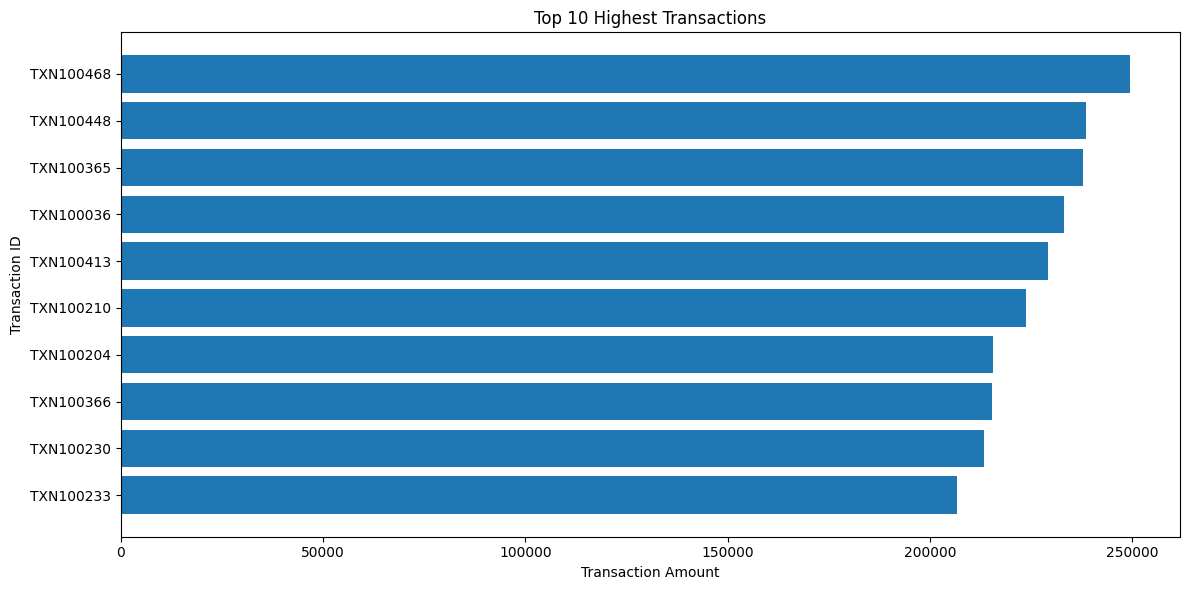

In [4]:
# --------------------------------------------------
# TOP 10 HIGHEST TRANSACTIONS
# --------------------------------------------------

top_10_transactions = df.nlargest(10, "Amount")

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_transactions["Transaction_ID"].astype(str),
    top_10_transactions["Amount"]
)

plt.title("Top 10 Highest Transactions")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("top_10_transactions.png")

plt.show()